# Data Prepration

In [ ]:
# LOAD

In [105]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [156]:
fg = pd.read_csv(r"C:\Users\dell\Downloads\fear_greed_index.csv")
hd = pd.read_csv(r"C:\Users\dell\Downloads\historical_data.csv")
TABLES = "Documents/"
CHARTS = "Documents/"

In [107]:
print("=== RAW SHAPES ===")
print("fear_greed_index : ", fg.shape)
print("historical_data : ", hd.shape)

=== RAW SHAPES ===
fear_greed_index :  (2644, 4)
historical_data :  (211224, 16)


In [108]:
print("=== MISSING VALUES  ===")
print("fear_greed_index -->")
print(fg.isna().sum())
print("historical_data -->")
print(hd.isna().sum())

=== MISSING VALUES  ===
fear_greed_index -->
timestamp         0
value             0
classification    0
date              0
dtype: int64
historical_data -->
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [109]:
print("\n=== DUPLICATES ===")
print("fear_greed_index.csv duplicate rows -->")
print(fg.duplicated().sum())
print("historical_data.csv duplicate rows -->")
print(hd.duplicated().sum())
print("historical_data.csv duplicate (Account, Order ID, Timestamp, Execution Price, Size Tokens) -->")
print(hd.duplicated(subset=["Account", "Order ID", "Timestamp IST", "Execution Price", "Size Tokens"]).sum())


=== DUPLICATES ===
fear_greed_index.csv duplicate rows -->
0
historical_data.csv duplicate rows -->
0
historical_data.csv duplicate (Account, Order ID, Timestamp, Execution Price, Size Tokens) -->
19964


In [110]:
# CLEAN and TRANSFORM

In [111]:
fg["date"] = pd.to_datetime(fg["date"]).dt.date
fg = fg.drop_duplicates(subset=["date"]).sort_values("date")
hd["ts"] = pd.to_datetime(hd["Timestamp IST"], format="%d-%m-%Y %H:%M")
hd["date"] = hd["ts"].dt.date

In [112]:
before = len(hd)
hd = hd.drop_duplicates()
print(f"\nDropped {before - len(hd)} exact duplicate rows")


Dropped 0 exact duplicate rows


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [114]:
hd = hd.reset_index(drop=True)
hd["row_id"] = hd.index

In [115]:
#overlap window between the two datasets
trade_min, trade_max = hd["date"].min(), hd["date"].max()
fg_min, fg_max = fg["date"].min(), fg["date"].max()
print(f"\nTrader data date range   : {trade_min} -> {trade_max}")
print(f"Sentiment data date range: {fg_min} -> {fg_max}")


Trader data date range   : 2023-05-01 -> 2025-05-01
Sentiment data date range: 2018-02-01 -> 2025-05-02


In [116]:
# Restrict sentiment to the window the trade log actually covers
fg_aligned = fg[(fg["date"] >= trade_min) & (fg["date"] <= trade_max)].copy()
print(f"Sentiment rows within trade-log window: {len(fg_aligned)}")

Sentiment rows within trade-log window: 731


In [117]:
# Collapse 5-way classification into a binary Fear/Greed flag as well (Neutral kept separate)
def to_binary(c):
    if "Fear" in c:
        return "Fear"
    if "Greed" in c:
        return "Greed"
    return "Neutral"

fg_aligned["sentiment_binary"] = fg_aligned["classification"].apply(to_binary)

print("\nSentiment classification counts:")
print(fg_aligned["classification"].value_counts())
print("\nBinary sentiment counts:")
print(fg_aligned["sentiment_binary"].value_counts())


Sentiment classification counts:
classification
Greed            294
Neutral          177
Fear             129
Extreme Greed    116
Extreme Fear      15
Name: count, dtype: int64

Binary sentiment counts:
sentiment_binary
Greed      410
Neutral    177
Fear       144
Name: count, dtype: int64


In [118]:

# REALIZED-TRADE FLAG
#  --> Many rows are position-building fills with Closed PnL == 0 (opens).
#  --> Only fills that actually close/reduce a position realize PnL.

print("\nDirection value counts:")
print(hd["Direction"].value_counts())


Direction value counts:
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64


In [119]:
closing_directions = {
    "Close Long", "Close Short", "Long > Short", "Short > Long",
    "Liquidated Isolated Short", "Auto-Deleveraging", "Settlement"}
hd["is_realized"] = (hd["Closed PnL"] != 0) | (hd["Direction"].isin(closing_directions))
print(f"\nRows with non-zero Closed PnL are {(hd['Closed PnL'] != 0).sum()} out of {len(hd)}")


Rows with non-zero Closed PnL are 104408 out of 211224


In [120]:
# Long/short flag per trade (based on Direction where possible, else Side)
def long_short(row):
    d = row["Direction"]
    if "Long" in d:
        return "Long"
    if "Short" in d:
        return "Short"
    return "Long" if row["Side"] == "BUY" else "Short"

hd["long_short"] = hd.apply(long_short, axis=1)

DAILY METRICS PER ACCOUNT

In [121]:

daily = hd.groupby(["Account", "date"]).agg(
    daily_pnl=("Closed PnL", "sum"),
    n_trades=("row_id", "count"),
    n_realized_trades=("is_realized", "sum"),
    avg_trade_size_usd=("Size USD", "mean"),
    total_volume_usd=("Size USD", "sum"),
    n_long=("long_short", lambda s: (s == "Long").sum()),
    n_short=("long_short", lambda s: (s == "Short").sum()),
    total_fees=("Fee", "sum"),
).reset_index()

In [122]:
# Win rate needs realized trades only
realized = hd[hd["Closed PnL"] != 0].copy()
realized["is_win"] = realized["Closed PnL"] > 0
win_daily = realized.groupby(["Account", "date"]).agg(
    n_wins=("is_win", "sum"),
    n_closed=("is_win", "count"),
).reset_index()
win_daily["win_rate"] = win_daily["n_wins"] / win_daily["n_closed"]

daily = daily.merge(win_daily[["Account", "date", "win_rate", "n_closed"]], on=["Account", "date"], how="left")
daily["long_short_ratio"] = daily["n_long"] / daily["n_short"].replace(0, np.nan)

MERGE WITH SENTIMENT

In [123]:

daily["date"] = pd.to_datetime(daily["date"]).dt.date
merged = daily.merge(fg_aligned[["date", "value", "classification", "sentiment_binary"]], on="date", how="left")

print("\nDaily-account rows before sentiment merge:", len(daily))
print("Daily-account rows after sentiment merge :", len(merged))
print("Rows with no sentiment match :", merged["sentiment_binary"].isna().sum())


Daily-account rows before sentiment merge: 2341
Daily-account rows after sentiment merge : 2341
Rows with no sentiment match : 1


# Analysis

In [125]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2341 entries, 0 to 2340
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Account             2341 non-null   object 
 1   date                2341 non-null   object 
 2   daily_pnl           2341 non-null   float64
 3   n_trades            2341 non-null   int64  
 4   n_realized_trades   2341 non-null   int64  
 5   avg_trade_size_usd  2341 non-null   float64
 6   total_volume_usd    2341 non-null   float64
 7   n_long              2341 non-null   int64  
 8   n_short             2341 non-null   int64  
 9   total_fees          2341 non-null   float64
 10  win_rate            1693 non-null   float64
 11  n_closed            1693 non-null   float64
 12  long_short_ratio    1568 non-null   float64
 13  value               2340 non-null   float64
 14  classification      2340 non-null   object 
 15  sentiment_binary    2340 non-null   object 
dtypes: flo

In [126]:
# Keep Fear vs Greed as the primary binary lens; Neutral shown for reference
order_binary = ["Fear", "Neutral", "Greed"]
order_5 = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

In [127]:
# Performance by sentiment (account-day level)

perf_by_sent = merged.groupby("sentiment_binary").agg(
    n_account_days=("daily_pnl", "count"),
    mean_daily_pnl=("daily_pnl", "mean"),
    median_daily_pnl=("daily_pnl", "median"),
    pct_profitable_days=("daily_pnl", lambda s: (s > 0).mean() * 100),
    mean_win_rate=("win_rate", "mean"),
).reindex(order_binary)
print("=== Performance by sentiment (account-day level) ===")
print(perf_by_sent)

=== Performance by sentiment (account-day level) ===
                  n_account_days  mean_daily_pnl  median_daily_pnl  \
sentiment_binary                                                     
Fear                         790     5185.146443        122.737038   
Neutral                      376     3438.618818        167.551743   
Greed                       1174     4144.208334        265.247725   

                  pct_profitable_days  mean_win_rate  
sentiment_binary                                      
Fear                        60.379747       0.842294  
Neutral                     62.234043       0.835721  
Greed                       64.310051       0.856307  


In [128]:
# Drawdown proxy: worst daily PnL per account, compared by sentiment day-type
# (i.e. how bad are the bad days under each regime)
worst_day_pct = merged.groupby("sentiment_binary")["daily_pnl"].quantile(0.05)
print("\n=== 5th percentile daily PnL (tail-loss / drawdown proxy) by sentiment ===")
print(worst_day_pct.reindex(order_binary))


=== 5th percentile daily PnL (tail-loss / drawdown proxy) by sentiment ===
sentiment_binary
Fear      -3484.972552
Neutral    -884.531466
Greed      -173.775756
Name: daily_pnl, dtype: float64


  Behavior by sentiment -->

In [129]:
behavior_by_sent = merged.groupby("sentiment_binary").agg(
    mean_trades_per_day=("n_trades", "mean"),
    mean_trade_size_usd=("avg_trade_size_usd", "mean"),
    mean_volume_usd=("total_volume_usd", "mean"),
    mean_long_short_ratio=("long_short_ratio", "mean"),
).reindex(order_binary)
print("\n=== Behavior by sentiment ===")
print(behavior_by_sent)


=== Behavior by sentiment ===
                  mean_trades_per_day  mean_trade_size_usd  mean_volume_usd  \
sentiment_binary                                                              
Fear                       105.363291          8529.859802    756720.318013   
Neutral                    100.228723          6963.694861    479367.189043   
Greed                       76.912266          5954.632633    351829.352036   

                  mean_long_short_ratio  
sentiment_binary                         
Fear                           2.927300  
Neutral                        2.965339  
Greed                          2.381213  


In [130]:
# Long vs short share directly from trade-level data

hd = hd.merge(fg_aligned[["date", "sentiment_binary", "classification"]], on="date", how="left")

ls_share = hd[hd["sentiment_binary"].notna()].groupby("sentiment_binary")["long_short"].value_counts(normalize=True).unstack() * 100
print("\n=== Long/Short share of trades (%) by sentiment ===")
print(ls_share.reindex(order_binary))


=== Long/Short share of trades (%) by sentiment ===
long_short             Long      Short
sentiment_binary                      
Fear              62.937155  37.062845
Neutral           61.367617  38.632383
Greed             44.191816  55.808184


Trader segmentation

In [131]:
account_summary = hd.groupby("Account").agg(
    total_volume_usd=("Size USD", "sum"),
    total_trades=("row_id", "count"),
    total_pnl=("Closed PnL", "sum"),
    avg_trade_size=("Size USD", "mean"),
).reset_index()

# Segment 1: activity level (trade count terciles)
account_summary["activity_segment"] = pd.qcut(
    account_summary["total_trades"], q=[0, 0.33, 0.66, 1.0], labels=["Infrequent", "Moderate", "Frequent"]
)

# Segment 2: position size (avg trade size terciles) -- proxy since true leverage multiplier isn't in this export
account_summary["size_segment"] = pd.qcut(
    account_summary["avg_trade_size"], q=[0, 0.33, 0.66, 1.0], labels=["Small size", "Mid size", "Large size"]
)

# Segment 3: consistency -- win rate computed per account across ALL realized trades,
# plus coefficient of variation of daily pnl (lower = more consistent)
realized = hd[hd["Closed PnL"] != 0].copy()
realized["is_win"] = realized["Closed PnL"] > 0
acct_win = realized.groupby("Account")["is_win"].mean().rename("overall_win_rate")

daily_acct_pnl = hd.groupby(["Account", "date"])["Closed PnL"].sum().reset_index()
pnl_std = daily_acct_pnl.groupby("Account")["Closed PnL"].std().rename("daily_pnl_std")
pnl_mean = daily_acct_pnl.groupby("Account")["Closed PnL"].mean().rename("daily_pnl_mean")

account_summary = account_summary.merge(acct_win, on="Account", how="left")
account_summary = account_summary.merge(pnl_std, on="Account", how="left")
account_summary = account_summary.merge(pnl_mean, on="Account", how="left")
account_summary["consistency_segment"] = pd.qcut(
    account_summary["overall_win_rate"].rank(method="first"), q=[0, 0.33, 0.66, 1.0],
    labels=["Inconsistent", "Average", "Consistent winners"]
)

account_summary.to_csv(f"{TABLES}/account_segments.csv", index=False)
print("\n=== Account segmentation summary (first 10 of 32) ===")
print(account_summary[["Account", "total_trades", "total_pnl", "overall_win_rate",
                        "activity_segment", "size_segment", "consistency_segment"]].head(10))

# Now: how does each segment's behavior/performance shift Fear -> Greed?
merged_seg = merged.merge(
    account_summary[["Account", "activity_segment", "size_segment", "consistency_segment"]],
    on="Account", how="left"
)
merged_seg.to_csv(f"{TABLES}/daily_account_metrics_with_segments.csv", index=False)

seg_sentiment = merged_seg.groupby(["activity_segment", "sentiment_binary"], observed=True).agg(
    mean_daily_pnl=("daily_pnl", "mean"),
    mean_trades=("n_trades", "mean"),
    mean_win_rate=("win_rate", "mean"),
).reset_index()
print("\n=== Activity segment x sentiment ===")
print(seg_sentiment)

size_sentiment = merged_seg.groupby(["size_segment", "sentiment_binary"], observed=True).agg(
    mean_daily_pnl=("daily_pnl", "mean"),
    mean_trade_size=("avg_trade_size_usd", "mean"),
    mean_win_rate=("win_rate", "mean"),
).reset_index()
print("\n=== Size segment x sentiment ===")
print(size_sentiment)

consist_sentiment = merged_seg.groupby(["consistency_segment", "sentiment_binary"], observed=True).agg(
    mean_daily_pnl=("daily_pnl", "mean"),
    mean_win_rate=("win_rate", "mean"),
).reset_index()
print("\n=== Consistency segment x sentiment ===")
print(consist_sentiment)


=== Account segmentation summary (first 10 of 32) ===
                                      Account  total_trades     total_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012          3818  1.600230e+06   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd          7280  4.788532e+04   
2  0x271b280974205ca63b716753467d5a371de622ab          3809 -7.043619e+04   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4         13311  1.324648e+05   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd          3239  1.686580e+05   
5  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891           815 -3.120360e+04   
6  0x39cef799f8b69da1995852eea189df24eb5cae3c          3589  1.445692e+04   
7  0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6           332  5.349625e+04   
8  0x420ab45e0bd8863569a5efbb9c05d91f40624641           383  1.995056e+05   
9  0x430f09841d65beb3f27765503d0f850b8bce7713          1237  4.165419e+05   

   overall_win_rate activity_segment size_segment consistency_segment  
0          0.792725      

In [152]:
# Save all summary tables for the write-up
perf_by_sent.to_csv(f"{TABLES}/perf_by_sentiment_binary.csv")

behavior_by_sent.to_csv(f"{TABLES}/behavior_by_sentiment.csv")
ls_share.to_csv(f"{TABLES}/long_short_share_by_sentiment.csv")
seg_sentiment.to_csv(f"{TABLES}/activity_segment_x_sentiment.csv", index=False)
size_sentiment.to_csv(f"{TABLES}/size_segment_x_sentiment.csv", index=False)
consist_sentiment.to_csv(f"{TABLES}/consistency_segment_x_sentiment.csv", index=False)

# CHARTS

In [133]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {"Fear": "#d64545", "Neutral": "#9a9a9a", "Greed": "#3f9142"}
order = ["Fear", "Neutral", "Greed"]

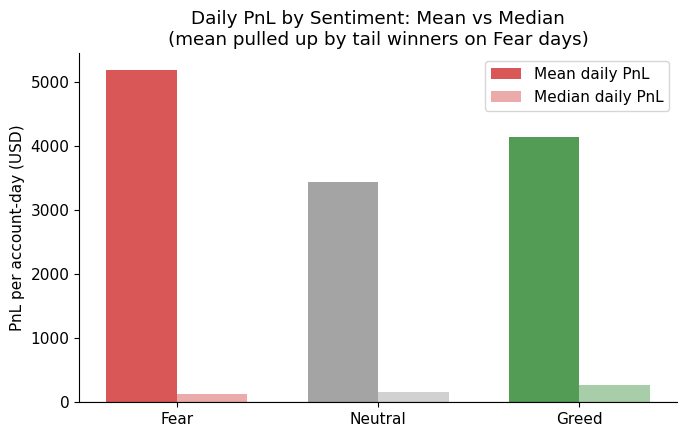

In [163]:

# Chart 1: Mean vs median daily PnL by sentiment (grouped bar)

perf = merged.groupby("sentiment_binary")[["daily_pnl"]].agg(["mean", "median"]).reindex(order)
perf.columns = ["mean", "median"]

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(order))
w = 0.35
ax.bar(x - w/2, perf["mean"], w, label="Mean daily PnL", color=[COLORS[o] for o in order], alpha=0.9)
ax.bar(x + w/2, perf["median"], w, label="Median daily PnL", color=[COLORS[o] for o in order], alpha=0.45)
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("PnL per account-day (USD)")
ax.set_title("Daily PnL by Sentiment: Mean vs Median\n(mean pulled up by tail winners on Fear days)")
ax.legend()
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(f"{CHARTS}/01_mean_median_pnl_by_sentiment.png", dpi=150)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

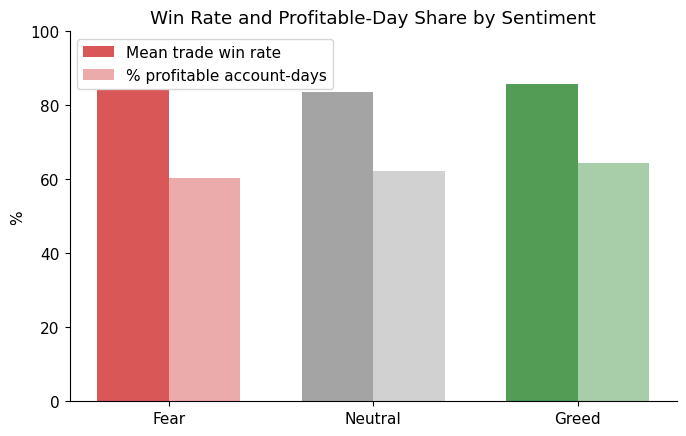

In [162]:
# Chart 2: Win rate & % profitable days by sentiment
wr = merged.groupby("sentiment_binary").agg(
    mean_win_rate=("win_rate", "mean"),
    pct_profitable_days=("daily_pnl", lambda s: (s > 0).mean()),
).reindex(order) * 100
wr["mean_win_rate"] = wr["mean_win_rate"]  
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - w/2, wr["mean_win_rate"], w, label="Mean trade win rate", color=[COLORS[o] for o in order], alpha=0.9)
ax.bar(x + w/2, wr["pct_profitable_days"], w, label="% profitable account-days", color=[COLORS[o] for o in order], alpha=0.45)
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("%")
ax.set_ylim(0, 100)
ax.set_title("Win Rate and Profitable-Day Share by Sentiment")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS}/02_winrate_profitable_days_by_sentiment.png", dpi=150)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

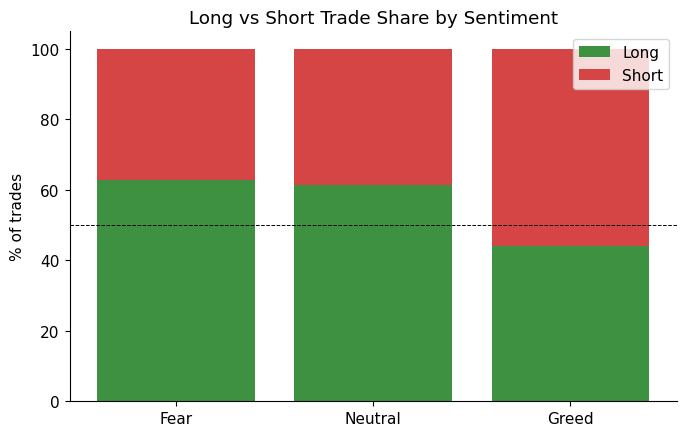

In [161]:

# Chart 3: Long/Short share by sentiment (stacked bar)
ls = pd.read_csv(f"{TABLES}/long_short_share_by_sentiment.csv", index_col=0).reindex(order)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(order, ls["Long"], label="Long", color="#3f9142")
ax.bar(order, ls["Short"], bottom=ls["Long"], label="Short", color="#d64545")
ax.set_ylabel("% of trades")
ax.set_title("Long vs Short Trade Share by Sentiment")
ax.axhline(50, color="black", linewidth=0.7, linestyle="--")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(f"{CHARTS}/03_long_short_share_by_sentiment.png", dpi=150)
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

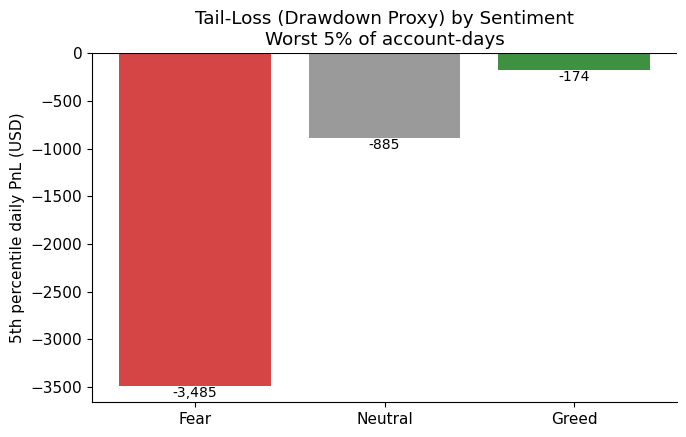

In [160]:
# Chart 4: Tail-risk (5th percentile daily PnL) by sentiment
tail = merged.groupby("sentiment_binary")["daily_pnl"].quantile(0.05).reindex(order)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(order, tail.values, color=[COLORS[o] for o in order])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("5th percentile daily PnL (USD)")
ax.set_title("Tail-Loss (Drawdown Proxy) by Sentiment\nWorst 5% of account-days")
for b, v in zip(bars, tail.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,.0f}", ha="center",
            va="top" if v < 0 else "bottom", fontsize=10)
plt.tight_layout()
plt.savefig(f"{CHARTS}/04_tail_risk_by_sentiment.png", dpi=150)
plt.show